# WAKE-NET: Wake-Aware Wind Farm Layout and Turbine Selection Optimization

This notebook provides a reproducible genetic-algorithm framework for optimizing wind farm layout, turbine selection, and farm dimensions while accounting for wake interactions, energy production, electrical collection costs, land use, and project economics.

It supports:

* Loading site-specific wind-speed and wind-direction data from an Excel file.
* Cleaning the wind dataset and generating a wind rose for visualizing the site’s wind resource.
* Converting historical wind measurements into wind-speed and wind-direction probability distributions.
* Identifying the three most frequently occurring wind directions at the selected site.
* Multiple user-defined turbine types with different rated powers, rotor diameters, hub heights, power coefficients, and capital costs.
* Wind-speed adjustment from the reference measurement height to each turbine’s hub height using either a logarithmic or power-law wind profile.
* Wake-loss modeling using a Jensen-style wake model.
* Partial wake-overlap calculations that account for rotor diameter, lateral displacement, and differences in turbine hub height.
* Square-root-of-sum-of-squares superposition for combining the effects of multiple upstream wakes.
* Wake-aware and wake-ignorant optimization through the `USE_WAKE_IN_OPT` switch.
* Annual Energy Production calculation across all wind-speed and wind-direction bins.
* Genetic-algorithm optimization of turbine positions, turbine types, and farm dimensions.
* Minimum inter-turbine spacing, farm-boundary, and substation-clearance constraints.
* Minimum-spanning-tree cable routing between turbines and the substation.
* Economic evaluation based on electricity revenue, annualized turbine capital cost, cable cost, operation and maintenance cost, and land cost.
* Annual Economic Benefit estimation for comparing candidate wind farm designs.
* Post-optimization wake-impact analysis for layouts developed without wake effects.
* Visualization of the optimized farm boundary, turbine locations and types, collection cables, substation, and wake regions associated with the dominant wind directions.
* A final summary of farm capacity, Annual Energy Production, capacity factor, cable length, annual costs, estimated annual economic benefit, and optimized turbine coordinates.

**Important:** The number of turbines is fixed through `N_TURBINES`; the optimization determines their locations, turbine types, and required farm dimensions. The input Excel file must contain the wind-data columns used by the notebook, including `WDIR`, `WSPD`, and `WSPD_80`. Wake-aware evaluation is computationally intensive because every candidate layout is evaluated across multiple wind-speed and wind-direction combinations. Begin with a small population and a limited number of generations to verify the setup before running a full optimization study.

## Associated Publication

This repository contains the implementation used in our research paper:

> **WAKE-NET: A 3D-wake-aware economic turbine layout and cabling optimization framework for multi-capacity multi-hub-height wind farms serving grid-scale and industrial power systems**

**Citation:** A. M. Toms and X. Li, "WAKE-NET: A 3D-wake-aware economic turbine layout and cabling optimization framework for multi-capacity multi-hub-height wind farms serving grid-scale and industrial power systems," *Renewable Energy*, vol. 273, pp. 126078, Oct. 2026.  
**DOI:** https://doi.org/10.1016/j.renene.2026.126078  
**Lab Website:** [Renewable Power Grids Lab, Univesity of Houston](https://rpglab.github.io/)

If you use this code, algorithms, or processed data in your research, **please cite the corresponding publication above.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, Circle
from windrose import WindroseAxes
import math
import random
from functools import lru_cache
import time
import pandas as pd
import copy

In [2]:
random.seed(42)
np.random.seed(42)

In [3]:
# Default / initial farm boundary (used before optimization)
default_bounds = (0.0, 8000.0, 0.0, 8000.0)  # starting guess
opt_bounds = default_bounds

In [4]:
# Substation position (set to None to place at farm center)
substation = None  # e.g., (1500, 1000)
substation_clearance = 250.0  # meters minimum distance to substation

In [5]:
# Number of turbines to place
N_TURBINES = 50

# Turbine types
turbine_types = [
    {  # type 0: "8MW"
        "name": "T8MW",
        "rated_power": 8e6,
        "rotor_diameter": 167.0,
        "hub_height": 90.0,
        "Cp": 0.45,
        "cost": 29_600_000.0,
    },
    {  # type 1: "11MW"
        "name": "T11MW",
        "rated_power": 11e6,
        "rotor_diameter": 200.0,
        "hub_height": 110.0,
        "Cp": 0.45,
        "cost": 40_700_000.0,
    },
    {  # type 2: "14MW"
        "name": "T14MW",
        "rated_power": 14e6,
        "rotor_diameter": 225.0,
        "hub_height": 125.0,
        "Cp": 0.45,
        "cost": 51_800_000.0,
    },
    {  # type 3: "16MW"
        "name": "T16MW",
        "rated_power": 16e6,
        "rotor_diameter": 262.0,
        "hub_height": 150.0,
        "Cp": 0.45,
        "cost": 59_200_000.0,
    },
    {  # type 4: "18MW"
        "name": "T18MW",
        "rated_power": 18e6,
        "rotor_diameter": 260.0,
        "hub_height": 160.0,
        "Cp": 0.45,
        "cost": 66_600_000.0,
    },
    {  # type 5: "22MW"
        "name": "T22MW",
        "rated_power": 22e6,
        "rotor_diameter": 310.0,
        "hub_height": 320.0,
        "Cp": 0.45,
        "cost": 81_400_000.0,
    }
]

In [6]:
# Reference height and shear for wind profile
wind_ref_height = 80.0  # m, height of the given speed_bins
roughness_length = 0.0002  # m, typical offshore
use_log_profile = True     # switch between log-law or power-law
alpha_shear = 0.12         # for power-law (if not using log profile)

In [7]:
# Wake model parameters
wake_decay_k = 0.04  # linear wake expansion coefficient (typical offshore values 0.03-0.06)
max_wake_length = 2500.0  # meters to draw / consider wakes

In [8]:
# Economic and other inputs
electricity_price_per_kwh = 0.41  # USD/kWh
lifetime_years = 20
discount_rate = 0.07

cable_cost_per_meter = 300.0  # USD per meter 
annual_OM_per_turbine = 800_000.0  # USD/year per turbine

# Land cost parameters
land_cost_per_m2 = 5.0  # USD per m^2
min_farm_size = (1000.0, 1000.0)
max_farm_size = (12000.0, 12000.0)

# Minimum turbine spacing multiplier (in rotor diameters)
min_spacing_multiplier = 3.0

In [9]:
# GA parameters
POP_SIZE = 50
GENERATIONS = 200
ELITE_COUNT = 4
MUTATION_POS_SIGMA = 100.0  
MUTATION_TYPE_PROB = 0.05

In [10]:
USE_WAKE_IN_OPT = True

In [11]:
xmin, xmax, ymin, ymax = opt_bounds
farm_area = (xmax - xmin) * (ymax - ymin)
if substation is None:
    substation = ((xmin + xmax) / 2.0, (ymin + ymax) / 2.0)

In [12]:
# Derived rotor areas
for t in turbine_types:
    t["rotor_area"] = math.pi * (t["rotor_diameter"] / 2.0) ** 2

RHO_AIR = 1.225  # kg/m^3

C:\Users\atoms2\AppData\Local\Temp\ipykernel_18092\48688143.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


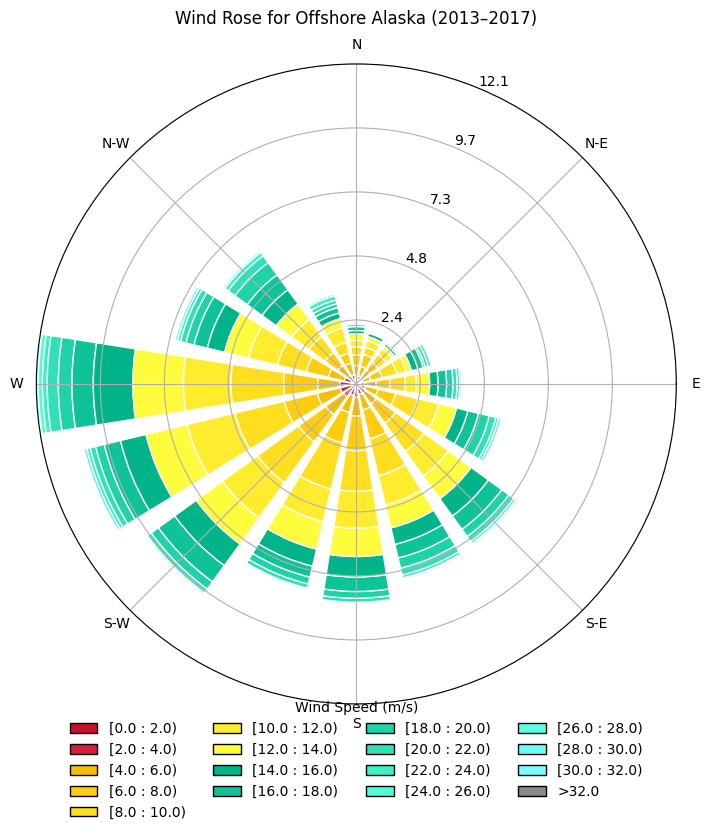

In [13]:
df = pd.read_excel('Alaska_all.xlsx')

# Convert columns to numeric
wind_direction = pd.to_numeric(df['WDIR'], errors='coerce')
wind_speed = pd.to_numeric(df['WSPD_80'], errors='coerce')

# Drop rows with NaNs
valid_data = pd.DataFrame({'WDIR': wind_direction, 'WSPD_80': wind_speed}).dropna()
wind_direction = valid_data['WDIR']
wind_speed = valid_data['WSPD_80']

# DEFINE BINS
# 2 m/s speed bins
speed_bins = np.arange(0, np.ceil(wind_speed.max()) + 2, 2)

# Count how many bins fall into each group
n_red = sum(speed_bins[1:] <= 4)
n_yellow = sum((speed_bins[1:] > 4) & (speed_bins[1:] <= 14))
n_green = sum((speed_bins[1:] > 14) & (speed_bins[1:] <= 32))
n_grey = sum(speed_bins[1:] > 32)

# Function to generate lightening shades of a base color
def generate_shades(base_hex, n):
    base_rgb = mcolors.to_rgb(base_hex)
    return [
        mcolors.to_hex([
            min(1, base_rgb[0] + i * 0.06),
            min(1, base_rgb[1] + i * 0.06),
            min(1, base_rgb[2] + i * 0.06)
        ]) for i in range(n)
    ]

# Generate shades
red_shades = generate_shades('#C8102E', n_red)
yellow_shades = generate_shades('#F6BE00', n_yellow)
green_shades = generate_shades('#00B388', n_green)
grey_shades = generate_shades('#888B8D', n_grey)

# Combine all into custom_colors list
custom_colors = red_shades + yellow_shades + green_shades + grey_shades

# CREATE WIND ROSE PLOT
fig = plt.figure(figsize=(8, 10))
ax = WindroseAxes.from_ax(fig=fig)
fig.add_axes(ax)

ax.bar(wind_direction, wind_speed,
       bins=speed_bins[:-1],
       colors=custom_colors,
       normed=True,
       opening=0.8,
       edgecolor='white')

# Custom legend
legend = ax.legend(loc='lower center', title='Wind Speed (m/s)', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=10, frameon=False)

plt.title("Wind Rose for Offshore Alaska (2013–2017)", pad=10)
plt.tight_layout()
plt.show()

In [14]:
# Clean and convert
df['WSPD'] = pd.to_numeric(df['WSPD'], errors='coerce')
df['WDIR'] = pd.to_numeric(df['WDIR'], errors='coerce')
df = df.dropna(subset=['WSPD', 'WDIR'])

# Extract arrays
wind_speeds_raw = df['WSPD'].values
wind_directions_raw = df['WDIR'].values

# WIND SPEED DISTRIBUTION
speed_bins = np.arange(0, 33, 1)  # 0–25 m/s in 1 m/s bins
speed_hist, _ = np.histogram(wind_speeds_raw, bins=speed_bins, density=False)
p_speed = speed_hist / speed_hist.sum()  # Normalize to sum to 1
wind_speeds = 0.5 * (speed_bins[:-1] + speed_bins[1:])  # bin midpoints

# WIND DIRECTION DISTRIBUTION
direction_bins = np.arange(0, 361, 30)  # 12 sectors (30° each)
direction_hist, _ = np.histogram(wind_directions_raw, bins=direction_bins, density=False)
p_dir = direction_hist / direction_hist.sum()  # Normalize to sum to 1
wind_directions = 0.5 * (direction_bins[:-1] + direction_bins[1:])  # bin midpoints

# DOMINANT WIND DIRECTION
dominant_dir = wind_directions[np.argmax(p_dir)]
print(f"Dominant wind direction: {dominant_dir:.1f}°")

# Print: show distributions
print("\nSpeed bins (m/s):", wind_speeds)
print("Speed probabilities:", p_speed)
print("\nDirection bins (°):", wind_directions)
print("Direction probabilities:", p_dir)

Dominant wind direction: 255.0°

Speed bins (m/s): [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5]
Speed probabilities: [8.37336625e-03 2.33040802e-02 3.97824356e-02 6.14851990e-02
 8.37336625e-02 1.01804389e-01 1.16073106e-01 1.13031499e-01
 1.01697038e-01 8.84481540e-02 6.94023241e-02 5.51425530e-02
 4.11601048e-02 3.22768221e-02 2.41092116e-02 1.73729458e-02
 1.01267635e-02 6.93307569e-03 3.82884696e-03 1.47607418e-03
 4.11511589e-04 1.78918082e-05 0.00000000e+00 8.94590412e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Direction bins (°): [ 15.  45.  75. 105. 135. 165. 195. 225. 255. 285. 315. 345.]
Direction probabilities: [0.02854638 0.02760706 0.04396017 0.06605656 0.09746563 0.10614315
 0.10999884 0.12614619 0.15383377 0.11986617 0.07977957 0.04059651]


In [15]:
# TOP 3 DOMINANT WIND DIRECTIONS 
sorted_indices = np.argsort(p_dir)[::-1]  # indices sorted from highest probability to lowest

top1_dir = wind_directions[sorted_indices[0]]
top2_dir = wind_directions[sorted_indices[1]]
top3_dir = wind_directions[sorted_indices[2]]

top1_prob = p_dir[sorted_indices[0]]
top2_prob = p_dir[sorted_indices[1]]
top3_prob = p_dir[sorted_indices[2]]

print("\nTop 3 dominant wind directions:")
print(f"1) {top1_dir:.1f}°   (prob={top1_prob:.4f})")
print(f"2) {top2_dir:.1f}°   (prob={top2_prob:.4f})")
print(f"3) {top3_dir:.1f}°   (prob={top3_prob:.4f})")


Top 3 dominant wind directions:
1) 255.0°   (prob=0.1538)
2) 225.0°   (prob=0.1261)
3) 285.0°   (prob=0.1199)


In [16]:
def wind_speed_at_height(U_ref, z, z_ref=wind_ref_height, z0=roughness_length, alpha=alpha_shear, use_log=use_log_profile):
    """
    Compute wind speed at hub height z given reference speed U_ref.
    Uses either logarithmic or power-law profile.
    """
    if use_log:
        # avoid math domain error if z0 >= z
        z = max(z, z0 * 1.0001)
        return U_ref * math.log(z / z0) / math.log(z_ref / z0)
    else:
        return U_ref * (z / z_ref) ** alpha

In [17]:
def power_from_wind(u, turbine):
    """
    Returns power in Watts produced by a turbine given freestream velocity u (m/s).
    Uses actuator-disk formula with turbine['Cp'] up to rated_power, then saturated at rated_power.
    Also respects a cut-in (~3 m/s) and cut-out (~32 m/s).
    """
    cut_in = 3.0
    cut_out = 32.0
    if u < cut_in or u >= cut_out:
        return 0.0
    P = 0.5 * RHO_AIR * turbine["Cp"] * turbine["rotor_area"] * u ** 3
    return min(P, turbine["rated_power"])

In [18]:
def solve_axial_induction_from_Cp(Cp):
    """
    Solve for axial induction factor 'a' using actuator disk theory: Cp = 4 a (1 - a)^2.
    Find real root in (0,1).
    """
    a_low, a_high = 1e-6, 0.499
    def f(a): return 4.0 * a * (1.0 - a) ** 2 - Cp
    if f(a_low) >= 0:
        return a_low
    for _ in range(80):
        a_mid = 0.5 * (a_low + a_high)
        if f(a_mid) == 0:
            return a_mid
        if f(a_low) * f(a_mid) < 0:
            a_high = a_mid
        else:
            a_low = a_mid
    return 0.3

In [19]:
def thrust_coefficient_from_Cp(Cp):
    a = solve_axial_induction_from_Cp(Cp)
    Ct = 4 * a * (1 - a)
    return Ct

# Precompute Ct per turbine type
for t in turbine_types:
    t["Ct"] = thrust_coefficient_from_Cp(t["Cp"])

In [20]:
def project_to_wind_frame(rel_vec, wind_from_deg):
    """
    Given relative vector rel_vec = (dx,dy) in Cartesian (x east, y north),
    and wind_from_deg (meteorological: degrees clockwise from North),
    return (x_downstream, lateral)
    """
    theta = math.radians(wind_from_deg)
    from_unit = np.array([math.sin(theta), math.cos(theta)])  # points from where wind comes
    downstream_unit = -from_unit
    lateral_unit = np.array([-downstream_unit[1], downstream_unit[0]])
    x_down = float(np.dot(rel_vec, downstream_unit))
    lat = float(np.dot(rel_vec, lateral_unit))
    return x_down, lat

In [21]:
def circle_intersection_area(R, r, d):
    """
    Area of intersection between two circles of radii R and r separated by distance d.
    """
    if d >= R + r:
        return 0.0
    if d <= abs(R - r):
        return math.pi * min(R, r) ** 2
    # general formula
    phi = math.acos((d ** 2 + R ** 2 - r ** 2) / (2 * d * R)) * 2.0
    theta = math.acos((d ** 2 + r ** 2 - R ** 2) / (2 * d * r)) * 2.0
    area = 0.5 * R ** 2 * (phi - math.sin(phi)) + 0.5 * r ** 2 * (theta - math.sin(theta))
    return area

In [22]:
def wake_deficit_jensen(up_t, down_t, rel_vec, wind_from_deg, k=wake_decay_k):
    """
    Compute the velocity deficit at downstream turbine due to a single upstream turbine (Jensen-style),
    adjusted by rotor/wake overlap area fraction. Returns deficit fraction (between 0 and 1).
    """
    x_down, lateral = project_to_wind_frame(rel_vec, wind_from_deg)
    if x_down <= 0.0:
        return 0.0
    D_up = up_t["rotor_diameter"]
    D_down = down_t["rotor_diameter"]
    Ct = up_t["Ct"]
    denom = (1.0 + 2.0 * k * (x_down / D_up))
    delta_center = (1.0 - math.sqrt(max(0.0, 1.0 - Ct))) / (denom ** 2)
    R_wake = 0.5 * D_up + k * x_down
    R_down = 0.5 * D_down
    z_up = up_t["hub_height"]
    z_down = down_t["hub_height"]
    dz = abs(z_up - z_down)
    d_3D = math.sqrt(lateral**2 + dz**2)
    A_overlap = circle_intersection_area(R_down, R_wake, d_3D)
    frac = A_overlap / (math.pi * R_down ** 2)
    frac = max(0.0, min(1.0, frac))
    return delta_center * frac

In [23]:
def effective_wind_at_turbine(idx, positions, types, wind_speed, wind_from_deg):
    """
    Compute effective wind speed at turbine idx given freestream wind_speed and other turbines' wakes.
    Uses SRSS superposition of deficits from all upstream turbines relative to this turbine for the given wind direction.
    """
    pos_i = positions[idx]
    t_i = turbine_types[types[idx]]
    deficits_sq = 0.0
    for j in range(len(positions)):
        if j == idx:
            continue
        pos_j = positions[j]
        t_j = turbine_types[types[j]]
        rel = np.array(pos_i) - np.array(pos_j)  # pos_i - pos_j (downstream relative to j)
        d = wake_deficit_jensen(t_j, t_i, rel, wind_from_deg)
        deficits_sq += d ** 2
    total_deficit = math.sqrt(deficits_sq)
    U_eff = wind_speed * max(0.0, 1.0 - total_deficit)
    return U_eff, total_deficit

In [24]:
@lru_cache(maxsize=1024)
def _hub_speed_cache(speed, hub_h, use_log):
    # small helper to cache wind_speed_at_height calls
    return wind_speed_at_height(speed, hub_h, use_log=use_log)

In [25]:
def compute_AEP(positions, types):
    """
    Compute annual energy production (kWh/year) of the whole farm by summing contributions across wind bins.
    Wake-aware calculation (uses effective_wind_at_turbine).
    """
    hours_per_year = 8760.0
    total_energy_Wh = 0.0

    # Precompute U_hub for each (turbine type, speed bin) to avoid repeated logs/calcs
    U_hub_lookup = {}
    for ispeed, speed in enumerate(wind_speeds):
        for t_idx, t in enumerate(turbine_types):
            key = (ispeed, t_idx)
            U_hub_lookup[key] = _hub_speed_cache(float(speed), float(t["hub_height"]), use_log_profile)

    # Loop over directions and speeds
    for idir, dir_deg in enumerate(wind_directions):
        for ispeed, speed in enumerate(wind_speeds):
            p = p_dir[idir] * p_speed[ispeed]
            power_total_W = 0.0
            # for each turbine compute U_eff considering wakes
            for i in range(len(positions)):
                t_type = turbine_types[types[i]]
                U_hub = U_hub_lookup[(ispeed, types[i])]
                U_eff, _ = effective_wind_at_turbine(i, positions, types, U_hub, dir_deg)
                P = power_from_wind(U_eff, t_type)
                power_total_W += P
            # energy for this wind case
            energy_Wh = power_total_W * hours_per_year * p
            total_energy_Wh += energy_Wh

    total_energy_kWh = total_energy_Wh / 1000.0
    return total_energy_kWh

In [26]:
def compute_AEP_no_wake(positions, types):
    """
    Faster approximate AEP that ignores wakes (useful for two-stage comparison).
    """
    hours_per_year = 8760.0
    total_energy_Wh = 0.0
    # Precompute hub speeds
    U_hub_lookup = {}
    for ispeed, speed in enumerate(wind_speeds):
        for t_idx, t in enumerate(turbine_types):
            key = (ispeed, t_idx)
            U_hub_lookup[key] = _hub_speed_cache(float(speed), float(t["hub_height"]), use_log_profile)
    for idir, dir_deg in enumerate(wind_directions):
        for ispeed, speed in enumerate(wind_speeds):
            p = p_dir[idir] * p_speed[ispeed]
            power_total_W = 0.0
            for i in range(len(positions)):
                t_type = turbine_types[types[i]]
                U_hub = U_hub_lookup[(ispeed, types[i])]
                P = power_from_wind(U_hub, t_type)
                power_total_W += P
            energy_Wh = power_total_W * hours_per_year * p
            total_energy_Wh += energy_Wh
    total_energy_kWh = total_energy_Wh / 1000.0
    return total_energy_kWh

In [27]:
def annualize_cost(capex, life=lifetime_years, r=discount_rate):
    if r == 0:
        return capex / life
    annuity = (r * (1 + r) ** life) / (((1 + r) ** life) - 1)
    return capex * annuity

In [28]:
def compute_cable_MST_and_cost(positions):
    """
    Compute MST over turbine nodes + substation and compute cable cost.
    Returns total_length_meters and list of edges for plotting.
    """
    nodes = positions + [substation]
    n = len(nodes)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                D[i, j] = 0.0
            else:
                D[i, j] = math.hypot(nodes[i][0] - nodes[j][0], nodes[i][1] - nodes[j][1])
    visited = set([0])
    edges = []
    total_len = 0.0
    while len(visited) < n:
        best = None
        best_d = float('inf')
        for i in visited:
            for j in range(n):
                if j in visited: continue
                if D[i, j] < best_d:
                    best_d = D[i, j]
                    best = (i, j)
        if best is None:
            break
        edges.append(best)
        total_len += best_d
        visited.add(best[1])
    return total_len, edges

In [29]:
def evaluate_layout(positions, types, verbose=False, use_wake=True):
    """
    Returns annual profit (USD/year) = revenue (AEP*kWh * price) - annualized turbine capex - cable annualized cost - O&M.
    Penalizes invalid layouts heavily by subtracting large penalty.
    `use_wake` decides whether AEP uses wake-aware compute_AEP or no-wake compute_AEP_no_wake.
    """
    positions = [tuple(p) for p in positions]
    bounds = globals().get("current_bounds", None)
    if bounds is None:
        xmin, xmax, ymin, ymax = farm_bounds  # fallback if not passed
    else:
        xmin, xmax, ymin, ymax = bounds

    penalty = 0.0
    # boundary check & substation clearance
    for i, p in enumerate(positions):
        if not (xmin <= p[0] <= xmax and ymin <= p[1] <= ymax):
            penalty += 1e8
        if math.hypot(p[0] - substation[0], p[1] - substation[1]) < substation_clearance:
            penalty += 5e7

    # inter-turbine spacing penalty
    for i in range(len(positions)):
        for j in range(i+1, len(positions)):
            d = math.hypot(positions[i][0] - positions[j][0], positions[i][1] - positions[j][1])
            min_d_local = min_spacing_multiplier * max(turbine_types[types[i]]["rotor_diameter"],
                                                      turbine_types[types[j]]["rotor_diameter"])
            if d < min_d_local:
                penalty += 1e7 * (min_d_local - d)

    # Compute AEP (kWh/year) - choose wake-aware or not based on parameter
    if use_wake:
        AEP_kWh = compute_AEP(positions, types)
    else:
        AEP_kWh = compute_AEP_no_wake(positions, types)

    revenue = AEP_kWh * electricity_price_per_kwh

    # Capex
    capex = sum(turbine_types[types[i]]["cost"] for i in range(len(positions)))
    annual_turbine_capex = annualize_cost(capex)

    # Cable cost (MST)
    total_len, edges = compute_cable_MST_and_cost(positions)
    cable_capex = total_len * cable_cost_per_meter
    annual_cable = annualize_cost(cable_capex)

    # O&M
    annual_om = annual_OM_per_turbine * len(positions)

    farm_area = (xmax - xmin) * (ymax - ymin)
    annual_land_cost = land_cost_per_m2 * farm_area
    annual_profit = revenue - (annual_turbine_capex + annual_cable + annual_om + annual_land_cost) - penalty

    if verbose:
        return {
            "AEP_kWh": AEP_kWh,
            "revenue": revenue,
            "annual_land_cost": annual_land_cost,
            "annual_turbine_capex": annual_turbine_capex,
            "annual_cable_capex": annual_cable,
            "annual_cable_length_m": total_len,
            "annual_om": annual_om,
            "penalty": penalty,
            "annual_profit": annual_profit,
            "edges": edges
        }
    return annual_profit

In [30]:
def create_individual():
    # Randomly choose farm width and height within allowed limits
    width = random.uniform(min_farm_size[0], max_farm_size[0])
    height = random.uniform(min_farm_size[1], max_farm_size[1])
    xmin, ymin = 0.0, 0.0
    xmax, ymax = xmin + width, ymin + height

    margin = max(t["rotor_diameter"] for t in turbine_types)
    pos = [(random.uniform(xmin + margin, xmax - margin), random.uniform(ymin + margin, ymax - margin))
           for _ in range(N_TURBINES)]
    types = [random.randrange(len(turbine_types)) for _ in range(N_TURBINES)]
    return pos, types, (xmin, xmax, ymin, ymax)

In [31]:
def mutate_individual(ind, pos_sigma=MUTATION_POS_SIGMA, type_mut_prob=MUTATION_TYPE_PROB):
    pos, types, bounds = ind
    xmin, xmax, ymin, ymax = bounds
    new_pos = []
    for (x, y) in pos:
        nx = x + random.gauss(0.0, pos_sigma)
        ny = y + random.gauss(0.0, pos_sigma)
        nx = min(max(nx, xmin), xmax)
        ny = min(max(ny, ymin), ymax)
        new_pos.append((nx, ny))
    new_types = []
    for t in types:
        if random.random() < type_mut_prob:
            available = list(range(len(turbine_types)))
            available.remove(t)
            new_types.append(random.choice(available))
        else:
            new_types.append(t)

    # mutate farm size slightly
    width = (xmax - xmin) * random.uniform(0.95, 1.05)
    height = (ymax - ymin) * random.uniform(0.95, 1.05)
    width = max(min_farm_size[0], min(width, max_farm_size[0]))
    height = max(min_farm_size[1], min(height, max_farm_size[1]))
    new_bounds = (0.0, width, 0.0, height)

    return new_pos, new_types, new_bounds

In [32]:
def crossover(a, b):
    pos_a, types_a, bounds_a = a
    pos_b, types_b, bounds_b = b
    child_pos = []
    child_types = []
    for i in range(len(pos_a)):
        child_pos.append(pos_a[i] if random.random() < 0.5 else pos_b[i])
        child_types.append(types_a[i] if random.random() < 0.5 else types_b[i])
    xmin = 0.0
    ymin = 0.0
    xmax = (bounds_a[1] + bounds_b[1]) / 2
    ymax = (bounds_a[3] + bounds_b[3]) / 2
    return child_pos, child_types, (xmin, xmax, ymin, ymax)

In [33]:
# ---------- GA runner (now supports wake-aware fitness) ----------
def run_ga(pop_size=POP_SIZE, generations=GENERATIONS, use_wake_in_eval=True):
    pop = [create_individual() for _ in range(pop_size)]
    best_history = []
    start = time.time()

    global_best_score = -float('inf')
    global_best_ind = None

    for gen in range(generations):
        scored = []
        for ind in pop:
            positions, types, bounds = ind
            globals()["current_bounds"] = bounds  # store for evaluate_layout
            score = evaluate_layout(positions, types, use_wake=use_wake_in_eval)
            scored.append((score, ind))

        # Sort by score desc
        scored.sort(key=lambda x: x[0], reverse=True)
        best_score, best_ind = scored[0]
        best_history.append(best_score)

        if best_score > global_best_score:
            global_best_score = best_score
            global_best_ind = copy.deepcopy(best_ind)

        if gen % max(1, generations // 5) == 0 or gen == generations - 1:
            print(f"GA gen {gen+1}/{generations} best profit USD/yr: {best_score:,.0f}")

        # elitism
        new_pop = [copy.deepcopy(ind) for (_, ind) in scored[:ELITE_COUNT]]

        # breeding
        top_half = [ind for (_, ind) in scored[: max(2, pop_size // 2)]]
        while len(new_pop) < pop_size:
            parent_a = random.choice(top_half)
            parent_b = random.choice(top_half)
            child = crossover(parent_a, parent_b)
            child = mutate_individual(child)
            new_pop.append(child)

        pop = new_pop

    elapsed = time.time() - start

    # Re-evaluate global best for a clean report (use same use_wake flag used in GA)
    positions, types, bounds = global_best_ind
    globals()["current_bounds"] = bounds
    final_score = evaluate_layout(positions, types, use_wake=use_wake_in_eval)

    print(f"GA finished in {elapsed:.1f}s. Best annual profit: USD {final_score:,.0f}")
    return global_best_ind, final_score, best_history

In [34]:
def plot_layout_with_wakes(positions, types, opt_bounds, dominant_case_index=None, show=True):
    xmin, xmax, ymin, ymax = opt_bounds
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_xlim(xmin - 100, xmax + 100)
    ax.set_ylim(ymin - 100, ymax + 100)
    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    ax.set_title("Optimized wind farm layout")
    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1)
    ax.add_patch(rect)

    # plot MST cabling
    _, edges = compute_cable_MST_and_cost(positions)
    nodes = positions + [substation]
    for (i, j) in edges:
        x1, y1 = nodes[i]
        x2, y2 = nodes[j]
        ax.plot([x1, x2], [y1, y2], linestyle='-', linewidth=1)

    # plot turbines
    for i, p in enumerate(positions):
        t = turbine_types[types[i]]
        markers = ["o", "s", "D", "^", "P", "X"]
        marker = markers[types[i] % len(markers)]
        ax.scatter(p[0], p[1], s=80, marker=marker)
        ax.text(p[0] + 12, p[1] + 12, f"{i}:{t['name']}", fontsize=9)

    # plot substation
    ax.scatter([substation[0]], [substation[1]], marker='*', s=120)
    ax.text(substation[0] + 12, substation[1] + 12, "Substation", fontsize=10)

    # dominant case
    if dominant_case_index is None:
        best_p = 0.0
        best_case = (None, None)
        for idir, dir_deg in enumerate(wind_directions):
            for ispeed, speed in enumerate(wind_speeds):
                p = p_dir[idir] * p_speed[ispeed]
                if p > best_p:
                    best_p = p
                    best_case = (dir_deg, speed)
        dominant_case = best_case
    else:
        dominant_case = dominant_case_index

    wind_from_deg, wind_speed = dominant_case
    ax.text(0.02, 0.02, f"Dominant wind: from {wind_from_deg}° at {wind_speed:.1f} m/s at {wind_ref_height}m", transform=ax.transAxes)

    # plot wake cones for dominant case
    for i, p in enumerate(positions):
        up_t = turbine_types[types[i]]
        theta = math.radians(wind_from_deg)
        from_unit = np.array([math.sin(theta), math.cos(theta)])
        downstream_unit = -from_unit
        num_steps = 40
        xs = []
        ys = []
        for step in range(num_steps + 1):
            xdist = (max_wake_length / num_steps) * step
            center = np.array(p) + downstream_unit * xdist
            width = up_t["rotor_diameter"] + 2 * wake_decay_k * xdist
            half = width / 2.0
            lateral_unit = np.array([-downstream_unit[1], downstream_unit[0]])
            left = center - lateral_unit * half
            right = center + lateral_unit * half
            xs.append((left[0], right[0]))
            ys.append((left[1], right[1]))
        left_points = [(xs[i][0], ys[i][0]) for i in range(len(xs))]
        right_points = [(xs[i][1], ys[i][1]) for i in reversed(range(len(xs)))]
        poly_pts = left_points + right_points
        poly = plt.Polygon(poly_pts, alpha=0.15)
        ax.add_patch(poly)

    ax.set_aspect('equal', adjustable='box')
    if show:
        plt.show()
    return fig, ax

In [35]:
def plot_layout_with_wakes1(positions, types, opt_bounds, show=True):

    xmin, xmax, ymin, ymax = opt_bounds
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot layout box + MST cabling + turbines

    ax.set_xlim(xmin - 100, xmax + 100)
    ax.set_ylim(ymin - 100, ymax + 100)
    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    ax.set_title("Optimized wind farm layout")

    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                         fill=False, linewidth=1)
    ax.add_patch(rect)

    # MST cabling
    _, edges = compute_cable_MST_and_cost(positions)
    nodes = positions + [substation]

    for (i, j) in edges:
        x1, y1 = nodes[i]
        x2, y2 = nodes[j]
        ax.plot([x1, x2], [y1, y2], linestyle='-', linewidth=1)

    # Turbines
    for i, p in enumerate(positions):
        t = turbine_types[types[i]]
        markers = ["o", "s", "D", "^", "P", "X"]
        marker = markers[types[i] % len(markers)]
        ax.scatter(p[0], p[1], s=80, marker=marker)
        ax.text(p[0] + 12, p[1] + 12, f"{i}:{t['name']}", fontsize=9)

    # Substation
    ax.scatter([substation[0]], [substation[1]], marker='*', s=120)
    ax.text(substation[0] + 12, substation[1] + 12, "Substation", fontsize=10)

    # Plotting (Top 3 Directions)

    top_dirs = [top1_dir, top2_dir, top3_dir]
    wake_colors = ["red", "blue", "green"]
    plot_speed = wind_speeds.max()

    # Show direction labels
    for rank, wind_dir in enumerate(top_dirs):
        ax.text(
            0.02, 0.02 + rank * 0.03,
            f"#{rank+1} wind: {wind_dir:.1f}° @ {plot_speed:.1f} m/s",
            transform=ax.transAxes,
            fontsize=8
        )

    # Draw concentric wakes
    for rank, wind_dir in enumerate(top_dirs):

        color = wake_colors[rank]
        alpha_scale = [1.0, 0.7, 0.45][rank]

        # Direction calculation
        theta = math.radians(wind_dir)
        from_unit = np.array([math.sin(theta), math.cos(theta)])
        downstream_unit = -from_unit

        for ti, p in enumerate(positions):

            up_t = turbine_types[types[ti]]
            D = up_t["rotor_diameter"]

            wake_length = max_wake_length
            resolution = 40
            ys = np.linspace(0, wake_length, resolution)
            sigma_spread = wake_decay_k

            for dy in ys:

                # Downstream wake center
                center = np.array(p) + downstream_unit * dy

                # Spread
                sigma = sigma_spread * dy + D / 2
                xs = np.linspace(-2.5 * sigma, 2.5 * sigma, 8)

                lateral_unit = np.array([-downstream_unit[1], downstream_unit[0]])

                for x in xs:

                    alpha = np.exp(-0.5 * (x / sigma)**2)
                    if alpha < 0.05:
                        continue

                    radius = D * 0.5 * (1 - alpha * 0.5)
                    ccenter = center + x * lateral_unit

                    circle = plt.Circle(
                        (ccenter[0], ccenter[1]),
                        radius,
                        color=color,
                        alpha=0.03 * alpha * alpha_scale,
                        linewidth=0
                    )
                    ax.add_patch(circle)

    ax.set_aspect("equal", adjustable="box")

    if show:
        plt.show()

    return fig, ax


In [36]:
print("Starting optimization (wake-aware during GA = {})...".format(USE_WAKE_IN_OPT))
best_individual, best_score, history = run_ga(use_wake_in_eval=USE_WAKE_IN_OPT)
best_positions, best_types, opt_bounds = best_individual
metrics = evaluate_layout(best_positions, best_types, verbose=True, use_wake=USE_WAKE_IN_OPT)
farm_capacity_MW = sum(turbine_types[best_types[i]]["rated_power"] for i in range(len(best_positions))) / 1e6  # MW
capacity_kW = farm_capacity_MW * 1000.0
farm_efficiency = metrics["AEP_kWh"] / (farm_capacity_MW * 1e3 * 8760.0) if farm_capacity_MW > 0 else 0.0
xmin, xmax, ymin, ymax = opt_bounds


Starting optimization (wake-aware during GA = True)...
GA gen 1/200 best profit USD/yr: -48,231,086,419
GA gen 41/200 best profit USD/yr: -3,409,242,390
GA gen 81/200 best profit USD/yr: 70,274,587
GA gen 121/200 best profit USD/yr: 226,815,139
GA gen 161/200 best profit USD/yr: 357,606,655
GA gen 200/200 best profit USD/yr: 368,451,247
GA finished in 109378.6s. Best annual profit: USD 368,451,247


In [37]:
if not USE_WAKE_IN_OPT:
    print("\n POST OPTIMIZATION WAKE IMPACT ANALYSIS ")

    # Re-evaluate the SAME layout but with wakes enabled
    wake_metrics = evaluate_layout(
        best_positions,
        best_types,
        verbose=True,
        use_wake=True
    )

    # Derived quantities
    wake_capacity_factor = (
        wake_metrics["AEP_kWh"] /
        (farm_capacity_MW * 1e3 * 8760.0)
        if farm_capacity_MW > 0 else 0.0
    )

    # Differences
    delta_AEP = wake_metrics["AEP_kWh"] - metrics["AEP_kWh"]
    delta_profit = wake_metrics["annual_profit"] - metrics["annual_profit"]

    print(f"AEP without wakes (optimized): {metrics['AEP_kWh'] / 1e6:,.3f} GWh/year")
    print(f"AEP with wakes applied:        {wake_metrics['AEP_kWh'] / 1e6:,.3f} GWh/year")
    print(f"AEP loss due to wakes:         {delta_AEP / 1e6:,.3f} GWh/year")

    print(f"\nAEB (no wakes): USD {metrics['annual_profit']:,.0f}/yr")
    print(f"AEB (with wakes): USD {wake_metrics['annual_profit']:,.0f}/yr")
    print(f"AEB impact of wakes: USD {delta_profit:,.0f}/yr")

    print(f"\nCapacity factor (no wakes):  {farm_efficiency*100:.2f}%")
    print(f"Capacity factor (with wakes): {wake_capacity_factor*100:.2f}%")


In [ ]:
print("\n OPTIMIZED LAYOUT SUMMARY")
print(f"Annual energy (AEP): {metrics['AEP_kWh'] / 1e6:,.3f} GWh/year")
print(f"Annual revenue (APB): USD {metrics['revenue']:,.0f}")
print(f"Farm capacity: {farm_capacity_MW:.2f} MW")
print(f"Farm efficiency (capacity factor): {farm_efficiency*100:.2f}%")
print(f"Annualized turbine capex: USD {metrics['annual_turbine_capex']:,.0f}/yr")
print(f"Annualized cable capex: USD {metrics['annual_cable_capex']:,.0f}/yr (cable length {metrics['annual_cable_length_m']:.0f} m)")
print(f"Annual O&M (turbines): USD {metrics['annual_om']:,.0f}/yr")
print(f"Penalty: USD {metrics['penalty']:,.0f}")
print(f"Optimized farm size: {xmax - xmin:.0f} m × {ymax - ymin:.0f} m (area {((xmax - xmin)*(ymax - ymin))/1e6:.2f} km²)")
print(f"Annual land cost: USD {metrics['annual_land_cost']:,.0f}/yr")
print(f"Estimated annual profit(AEB): USD {metrics['annual_profit']:,.0f}/yr")

fig, ax = plot_layout_with_wakes1(best_positions, best_types, opt_bounds)
print("\nTurbine positions and types:")
for i, p in enumerate(best_positions):
    t = turbine_types[best_types[i]]
    print(f"  Turbine {i}: Type {best_types[i]} ({t['name']}), pos=({p[0]:.1f}, {p[1]:.1f}), rotor D={t['rotor_diameter']:.1f} m")



 OPTIMIZED LAYOUT SUMMARY
Annual energy (AEP): 3,000.833 GWh/year
Annual revenue (APB): USD 1,230,341,507
Farm capacity: 741.00 MW
Farm efficiency (capacity factor): 46.23%
Annualized turbine capex: USD 258,797,085/yr
Annualized cable capex: USD 1,747,012/yr (cable length 61693 m)
Annual O&M (turbines): USD 40,000,000/yr
Penalty: USD 0
Optimized farm size: 10939 m × 10263 m (area 112.27 km²)
Annual land cost: USD 561,346,163/yr
Estimated annual profit(AEB): USD 368,451,247/yr
